# 29c · GSE135779 · scRNA_seq · pvclust-py: which gene clusters are supported? (Python)

Reads `hub_matrix.csv` and `hub_genes.csv` (written by notebook 28). Writes
`pvclust_genes.pkl` in `data/run_artifacts/GSE135779/` and the dendrogram to `figures/GSE135779/`.

**Method.** Hierarchical clustering with approximately unbiased (AU) p-values from multiscale bootstrap
resampling (Suzuki R, Shimodaira H. Pvclust: an R package for assessing the uncertainty in hierarchical
clustering. *Bioinformatics* 2006;22:1540-1542, doi:10.1093/bioinformatics/btl117; multiscale bootstrap:
Shimodaira H. An approximately unbiased test of phylogenetic tree selection. *Syst Biol* 2002;51:492-508,
doi:10.1080/10635150290069913). A cluster with AU >= 0.95 is supported at the 5% level: it would reappear
if another sample of patients were drawn from the same population.

**Implementation.** pvclust-py (NIH-NLM/pvclust-py, pinned in `endotypes-transcriptomics.yml` to commit
6b0c3bf), a line-by-line Python port of R pvclust 2.2-0 checked against R fixtures.

| setting | value | reason |
|---|---|---|
| objects clustered | the GSE65391 hub genes measured here | this notebook asks about gene groups |
| resampling units | the 33 children with SLE | pvclust-py documentation: resampling samples to cluster analytes is "the sound direction" |
| distance | `minkowski` (p = 2, Euclidean) | as in the R heatmaps; pvclust's minkowski is always p = 2 |
| linkage | `ward.D2` | as in the R heatmaps |
| bootstrap replicates | 1,000 per scale | R pvclust's default |
| scales r | 0.5 to 1.4 by 0.1 | R pvclust's default |
| seed | 20260928 | the project seed |

**No k.** The tree is not cut at a number of groups. `pvpick` (alpha = 0.95, largest non-overlapping
clusters first) returns the clusters that clear the AU threshold.

**Test.** Each significant gene cluster against the GSE65391 modules: does it hold the hub genes of one
module, or mix modules? pvclust-py warns when fewer than 30 units are resampled: here there are 33.

## Load the matrix written by notebook 28

In [1]:
import pickle, collections
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from pvclust_py.core import pvclust, pvpick
from pvclust_py.plot import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "endotypes-transcriptomics.yml").exists())
ART  = ROOT / "data" / "run_artifacts" / "GSE135779"
FIG  = ROOT / "figures" / "GSE135779"; FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260928
pd.set_option("display.max_colwidth", None)   # show every cluster member

X     = pd.read_csv(ART / "hub_matrix.csv", index_col=0)     # patients x genes
genes = pd.read_csv(ART / "hub_genes.csv").set_index("gene")["module"]
X.shape

(33, 119)

**Explanation**
- `pandas` holds tables in Python (McKinney W. Data structures for statistical computing in Python.
  *Proceedings of the 9th Python in Science Conference* 2010:56-61).
- As in notebook 08c, with the matrix of notebook 28: the children of this study by the GSE65391 hub genes
  measured here.

## Run pvclust on the genes

In [2]:
res = pvclust(X, cluster="columns", method_dist="minkowski", method_hclust="ward.D2",
              nboot=1000, seed=SEED)
edges = res.edges_frame()
edges[["size", "au", "bp"]].describe() if "size" in edges else edges[["au", "bp"]].describe()

,au,bp
count,118.000000,118.000000
mean,0.715205,0.222015
std,0.297848,0.223588
min,0.000000,0.000000
25%,0.681816,0.023684
50%,0.823421,0.146775
75%,0.902294,0.374222
max,1.000000,1.000000


**Explanation**
- As in notebook 08c. The genes are clustered and the children are resampled; with fewer than 30 children,
  pvclust-py warns that AU is poorly determined.

## Pick the supported clusters

In [3]:
picked = pvpick(res, alpha=0.95)
rows = []
for e in picked:
    mods = collections.Counter(genes[m] for m in e["members"])
    rows.append({"genes": len(e["members"]), "AU": round(e["au"], 3), "BP": round(e["bp"], 3),
                 "modules": ", ".join(f"{k} ({v})" for k, v in mods.most_common())})
table = pd.DataFrame(rows).sort_values("genes", ascending=False).reset_index(drop=True)
print(f"{len(picked)} significant gene clusters (AU >= 0.95)")
table

9 significant gene clusters (AU >= 0.95)


,genes,AU,BP,modules
0,20,0.985,0.026,"black (10), pink (9), brown (1)"
1,9,0.961,0.251,"yellow (3), green (2), turquoise (2), magenta (1), red (1)"
2,5,0.971,0.052,"blue (3), salmon (2)"
3,4,0.973,0.302,"magenta (1), blue (1), tan (1), greenyellow (1)"
4,3,0.966,0.414,"salmon (2), magenta (1)"
5,3,0.970,0.470,turquoise (3)
6,2,0.959,0.702,brown (2)
7,2,0.951,0.567,"tan (1), turquoise (1)"
8,2,0.995,0.786,"turquoise (1), yellow (1)"


**Explanation**
- As in notebook 08c: each cluster's number of genes, AU, BP, and the GSE65391 modules of its genes.

**Test.** How many significant clusters hold the hub genes of a single module only, and how many of the
14 modules are exactly one significant cluster (all 10 hub genes, nothing else)?

In [4]:
single = sum(1 for e in picked if len({genes[m] for m in e["members"]}) == 1)
exact  = sum(1 for mo in genes.unique()
             if any(set(e["members"]) == set(genes.index[genes == mo]) for e in picked))
print(f"significant clusters from a single module: {single} of {len(picked)}")
print(f"modules recovered exactly as one significant cluster: {exact} of {genes.nunique()}")

significant clusters from a single module: 2 of 9
modules recovered exactly as one significant cluster: 0 of 14


**Explanation**
- As in notebook 08c: clusters from a single module, and modules recovered exactly as one cluster.

**Result.** 9 gene clusters with AU >= 0.95 (BP 0.026 to 0.786), two from a single GSE65391 module; none
reproduces a module exactly. All 10 interferon hub genes (black) lie in one supported cluster of 20 genes,
together with 9 plasma-cell (pink) hub genes and one brown gene: AU = 0.985, BP = 0.026.

AU is the approximately unbiased p-value from the multiscale bootstrap; BP is the ordinary bootstrap probability, which is biased (Suzuki and Shimodaira 2006). A cluster with high AU and low BP is supported only after the multiscale correction.

## Draw the tree with AU and BP

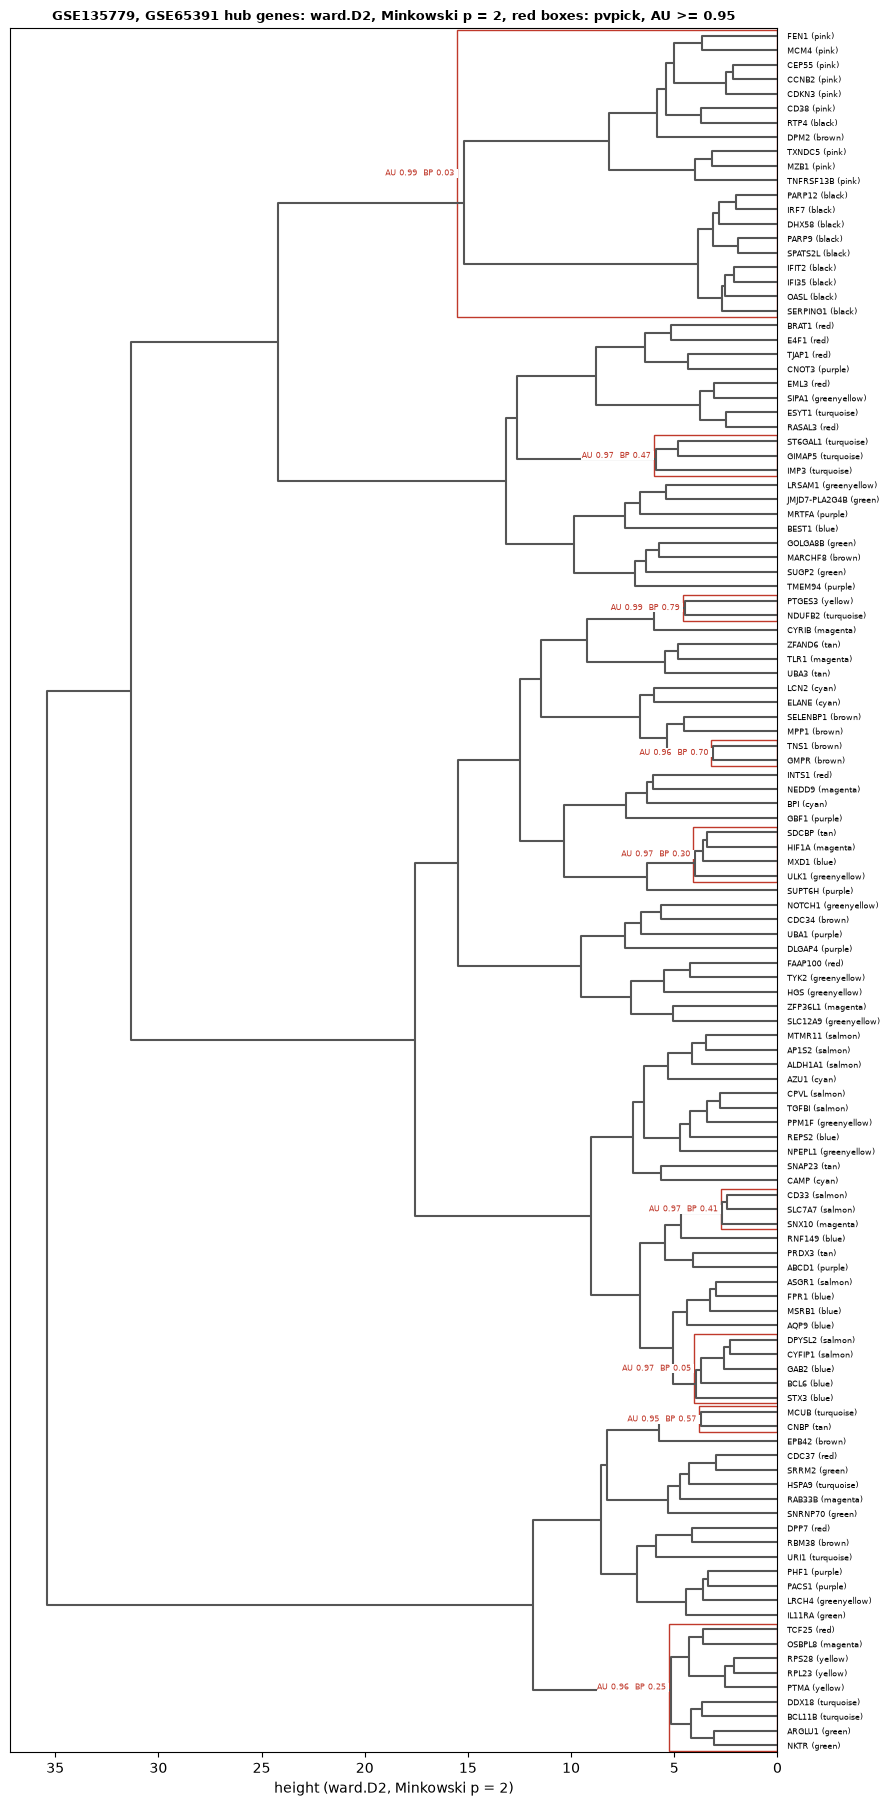

In [5]:
# The pvclust tree with every label shown. Each red box is one pvpick cluster (AU >= 0.95),
# labelled with its AU and BP values (AU: approximately unbiased; BP: ordinary bootstrap).
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import dendrogram as tree

def pv_figure(res, picked, leaf_text, title, path):
    n = len(res.labels)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.14 * n + 1.5)))
    d = tree(res.linkage, labels=[leaf_text[l] for l in res.labels], orientation="left", ax=ax,
             color_threshold=0, above_threshold_color="#555555", leaf_font_size=6)
    pos = {res.labels[j]: 5 + 10 * k for k, j in enumerate(d["leaves"])}
    for e in picked:
        ys = [pos[m] for m in e["members"]]
        h = res.linkage[e["merge_order"] - 1, 2] * 1.02
        ax.add_patch(Rectangle((0, min(ys) - 4), h, max(ys) - min(ys) + 8, fill=False, edgecolor="#C0392B", lw=1))
        ax.text(h, (min(ys) + max(ys)) / 2, f"AU {e['au']:.2f}  BP {e['bp']:.2f} ", color="#C0392B",
                fontsize=6, ha="right", va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3))
    ax.set_xlabel("height (ward.D2, Minkowski p = 2)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()

leaf_text = {g: f"{g} ({genes[g]})" for g in res.labels}
pv_figure(res, picked, leaf_text, "GSE135779, GSE65391 hub genes: ward.D2, Minkowski p = 2, red boxes: pvpick, AU >= 0.95", FIG / "29c_GSE135779_scRNA_seq_pvclust_genes.png")

**Explanation**
- `matplotlib` draws the figure (Hunter JD. Matplotlib: a 2D graphics environment. *Comput Sci Eng*
  2007;9:90-95); `scipy.cluster.hierarchy.dendrogram` draws the tree from the linkage matrix (Virtanen P et
  al. SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nat Methods* 2020;17:261-272).
- As in notebook 08c.

## Save

In [6]:
pickle.dump(res, open(ART / "pvclust_genes.pkl", "wb"))

**Explanation**
- As in notebook 08c; the two-way figure of the next notebook reads this result.